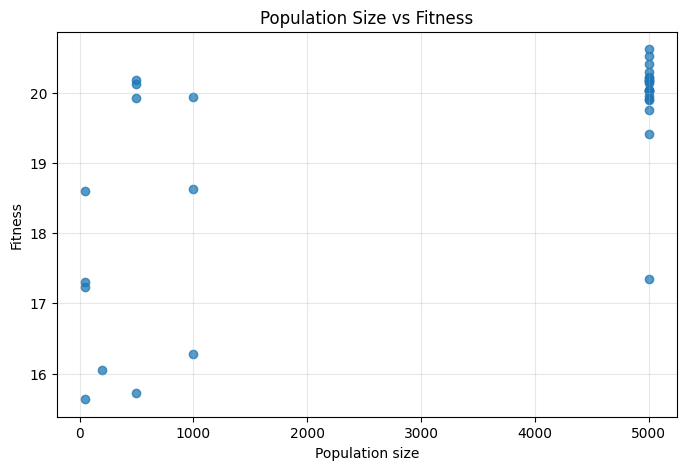

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path('../log/hpo_20260614_155712.csv')
df = pd.read_csv(csv_path)
fitness_col = 'avg_fitness'

plt.figure(figsize=(8, 5))
plt.scatter(df['populationSize'], df[fitness_col], alpha=0.75)
plt.xlabel('Population size')
plt.ylabel('Fitness')
plt.title('Population Size vs Fitness')
plt.grid(True, alpha=0.3)
plt.show()

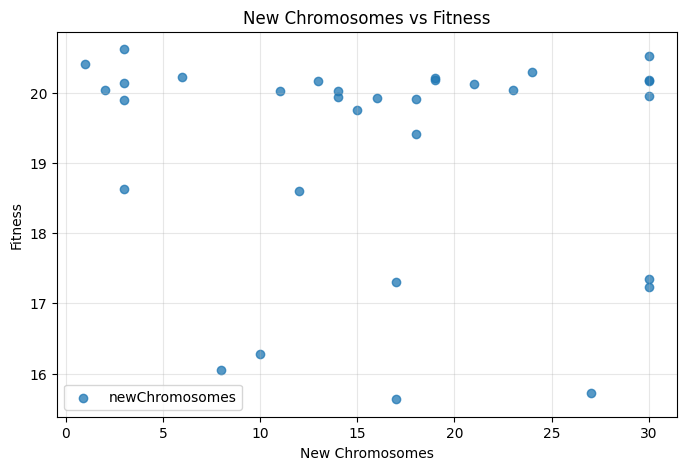

In [9]:
crossover_prob_cols = [
    'newChromosomes',
]

plt.figure(figsize=(8, 5))
for col in crossover_prob_cols:
    plt.scatter(df[col], df[fitness_col], alpha=0.75, label=col)

plt.xlabel('New Chromosomes')
plt.ylabel('Fitness')
plt.title('New Chromosomes vs Fitness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\stjep\AppData\Local\Temp\ipykernel_20196\3588267272.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(selection_data, labels=selection_order)


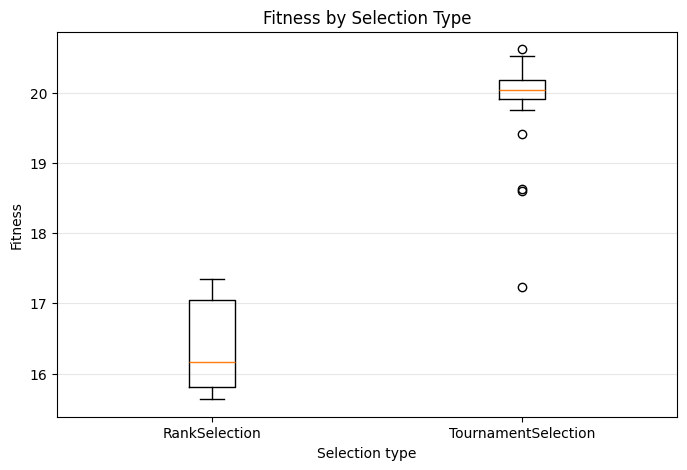

In [5]:
selection_order = ['RankSelection', 'TournamentSelection']
selection_data = [
    df.loc[df['selection_type'] == selection_type, fitness_col]
    for selection_type in selection_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(selection_data, labels=selection_order)
plt.xlabel('Selection type')
plt.ylabel('Fitness')
plt.title('Fitness by Selection Type')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

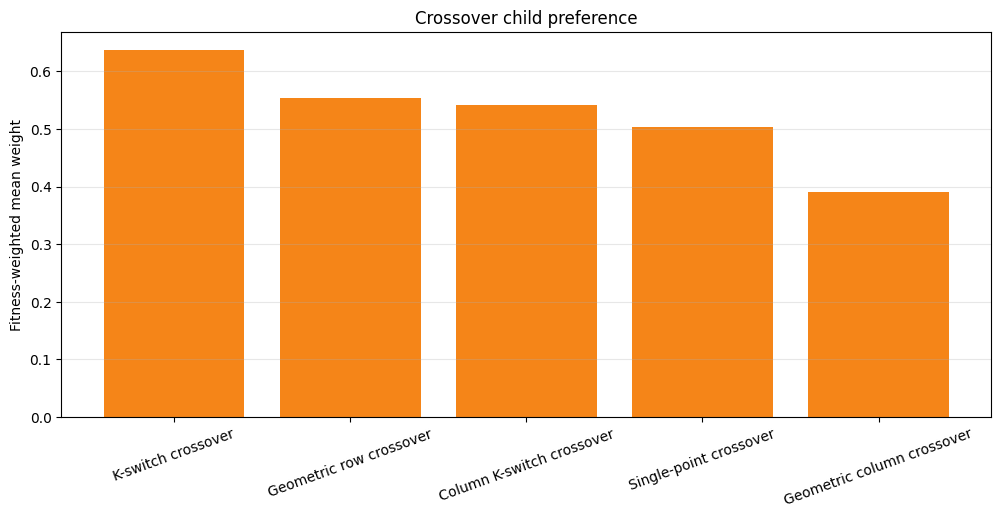

In [12]:
fitness = df[fitness_col]
total_fitness = fitness.sum()

child_weight_cols = {
    'crossover_child1_weight': 'Geometric column crossover',
    'crossover_child2_weight': 'Geometric row crossover',
    'crossover_child3_weight': 'Single-point crossover',
    'crossover_child4_weight': 'K-switch crossover',
    'crossover_child5_weight': 'Column K-switch crossover',
}

summary = pd.DataFrame(
    {
        'fitness_weighted_mean_weight': {
            label: (df[col] * fitness).sum() / total_fitness
            for col, label in child_weight_cols.items()
        },
        'mean_weight': {
            label: df[col].mean()
            for col, label in child_weight_cols.items()
        },
    }
).sort_values('fitness_weighted_mean_weight', ascending=False)

summary['fitness_weighted_share'] = summary['fitness_weighted_mean_weight'] / summary['fitness_weighted_mean_weight'].sum()

plt.figure(figsize=(12, 5))
plt.bar(summary.index, summary['fitness_weighted_mean_weight'], color='#F58518')
plt.ylabel('Fitness-weighted mean weight')
plt.title('Crossover child preference')
plt.xticks(rotation=20)
plt.grid(True, axis='y', alpha=0.3)
plt.show()
